In [ ]:
"""
PREDICCIÓN DE PRECIOS DE VIVIENDAS - AMES HOUSING
===================================================
ENTRENAMIENTO Y COMPARACIÓN DE MODELOS
Autor: Tu Nombre
Fecha: 2026-07-07
"""

# Importaciones
import sys
from pathlib import Path

# Añadir raíz del proyecto al path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurar visualización
%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Crear carpeta para guardar gráficos
Path('../reports/figures/model_comparison').mkdir(parents=True, exist_ok=True)

print("✅ Configuración completada")
print(f"📁 Proyecto raíz: {project_root}")

✅ Configuración completada
📁 Proyecto raíz: <directorio del proyecto>


In [12]:
# Cargar datos procesados
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

print(f"📊 Datos cargados:")
print(f"  - X_train: {X_train.shape}")
print(f"  - X_test: {X_test.shape}")
print(f"  - y_train: {y_train.shape}")
print(f"  - y_test: {y_test.shape}")
print(f"\n🎯 Target stats:")
print(f"  - Train mean: ${y_train.mean():,.2f}")
print(f"  - Test mean: ${y_test.mean():,.2f}")

📊 Datos cargados:
  - X_train: (1113, 213)
  - X_test: (279, 213)
  - y_train: (1113,)
  - y_test: (279,)

🎯 Target stats:
  - Train mean: $175,589.04
  - Test mean: $179,290.89


In [13]:
# Modelos
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, learning_curve

# Métricas
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Para guardar modelos
import joblib

print("✅ Modelos y métricas importados")

✅ Modelos y métricas importados


In [14]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """
    Evalúa un modelo con múltiples métricas
    """
    # Entrenar
    model.fit(X_train, y_train)
    
    # Predicciones
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Métricas
    metrics = {
        'Model': model_name,
        'RMSE_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
        'MAE_train': mean_absolute_error(y_train, y_pred_train),
        'MAE_test': mean_absolute_error(y_test, y_pred_test),
        'R2_train': r2_score(y_train, y_pred_train),
        'R2_test': r2_score(y_test, y_pred_test),
    }
    
    # Validación cruzada (5 folds)
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    metrics['CV_mean'] = cv_scores.mean()
    metrics['CV_std'] = cv_scores.std()
    
    return metrics, model, y_pred_test

In [16]:
# Definir modelos base
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0, max_iter=5000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Evaluar cada modelo
results = []
predictions = {}
trained_models = {}

print("="*60)
print("🚀 ENTRENANDO MODELOS BASE")
print("="*60)

for name, model in models.items():
    print(f"\n📊 Entrenando {name}...")
    metrics, trained_model, y_pred = evaluate_model(
        model, X_train, X_test, y_train, y_test, name
    )
    results.append(metrics)
    predictions[name] = y_pred
    trained_models[name] = trained_model
    
    print(f"  - R2 Train: {metrics['R2_train']:.4f}")
    print(f"  - R2 Test: {metrics['R2_test']:.4f}")
    print(f"  - CV Mean: {metrics['CV_mean']:.4f} (+/- {metrics['CV_std']:.4f})")

🚀 ENTRENANDO MODELOS BASE

📊 Entrenando Linear Regression...
  - R2 Train: 0.9474
  - R2 Test: 0.8926
  - CV Mean: 0.9028 (+/- 0.0215)

📊 Entrenando Ridge...
  - R2 Train: 0.9460
  - R2 Test: 0.9030
  - CV Mean: 0.9127 (+/- 0.0198)

📊 Entrenando Lasso...
  - R2 Train: 0.9473
  - R2 Test: 0.8943
  - CV Mean: 0.9042 (+/- 0.0211)

📊 Entrenando Random Forest...
  - R2 Train: 0.9861
  - R2 Test: 0.8962
  - CV Mean: 0.8870 (+/- 0.0131)

📊 Entrenando XGBoost...
  - R2 Train: 0.9999
  - R2 Test: 0.9064
  - CV Mean: 0.8848 (+/- 0.0163)

📊 Entrenando Gradient Boosting...
  - R2 Train: 0.9729
  - R2 Test: 0.9145
  - CV Mean: 0.9087 (+/- 0.0152)


📊 COMPARACIÓN DE MODELOS
               Model  R2_train  R2_test  CV_mean  CV_std   RMSE_test
5  Gradient Boosting    0.9729   0.9145   0.9087  0.0152  21661.6199
4            XGBoost    0.9999   0.9064   0.8848  0.0163  22660.4515
1              Ridge    0.9460   0.9030   0.9127  0.0198  23064.2500
3      Random Forest    0.9861   0.8962   0.8870  0.0131  23864.7718
2              Lasso    0.9473   0.8943   0.9042  0.0211  24083.6327
0  Linear Regression    0.9474   0.8926   0.9028  0.0215  24269.1410


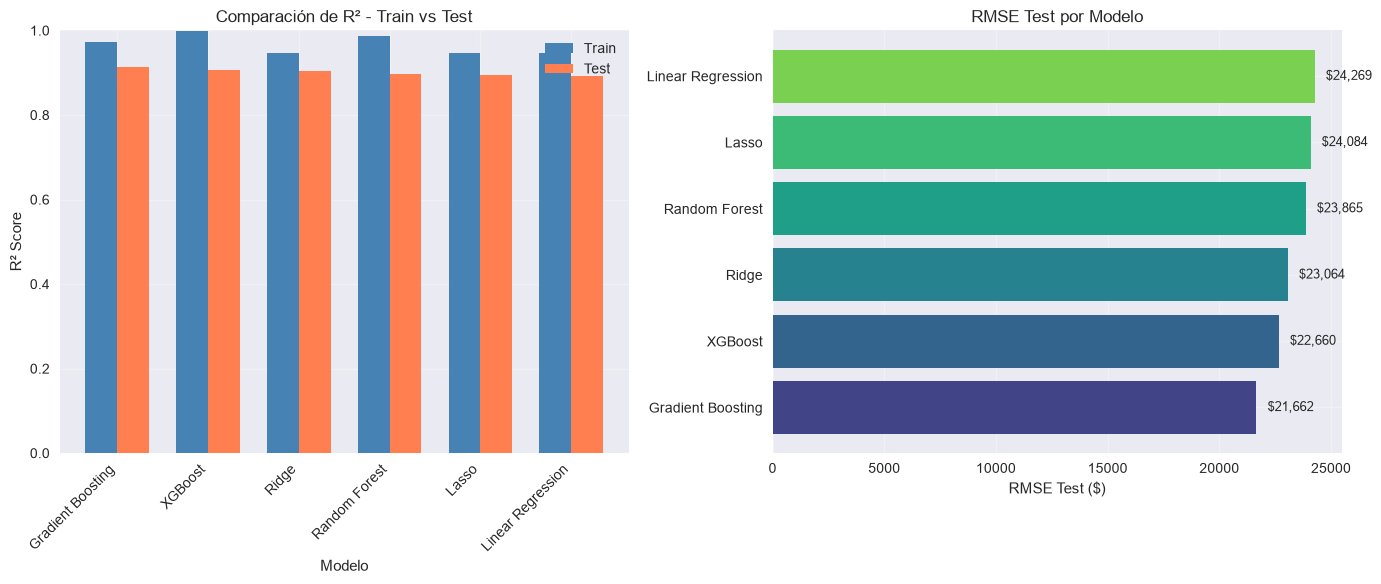


🏆 MEJOR MODELO (por R² Test):
  - Gradient Boosting
  - R² Test: 0.9145
  - RMSE Test: $21,661.62


In [17]:
# Crear DataFrame con resultados
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

# Ordenar por R2 Test
results_df = results_df.sort_values('R2_test', ascending=False)

print("="*60)
print("📊 COMPARACIÓN DE MODELOS")
print("="*60)
print(results_df[['Model', 'R2_train', 'R2_test', 'CV_mean', 'CV_std', 'RMSE_test']])

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Comparación R2
ax1 = axes[0]
x = np.arange(len(results_df))
width = 0.35

ax1.bar(x - width/2, results_df['R2_train'], width, label='Train', color='steelblue')
ax1.bar(x + width/2, results_df['R2_test'], width, label='Test', color='coral')
ax1.set_xlabel('Modelo')
ax1.set_ylabel('R² Score')
ax1.set_title('Comparación de R² - Train vs Test')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# 2. Comparación RMSE
ax2 = axes[1]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))
ax2.barh(results_df['Model'], results_df['RMSE_test'], color=colors)
ax2.set_xlabel('RMSE Test ($)')
ax2.set_title('RMSE Test por Modelo')
ax2.grid(True, alpha=0.3)

# Añadir valores
for i, v in enumerate(results_df['RMSE_test']):
    ax2.text(v + 500, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n🏆 MEJOR MODELO (por R² Test):")
best_model = results_df.iloc[0]
print(f"  - {best_model['Model']}")
print(f"  - R² Test: {best_model['R2_test']:.4f}")
print(f"  - RMSE Test: ${best_model['RMSE_test']:,.2f}")

In [18]:
# Tuning para Random Forest (el mejor generalmente)
print("="*60)
print("🔧 TUNING DE HIPERPARÁMETROS - RANDOM FOREST")
print("="*60)

# Definir grid de parámetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf, 
    param_grid, 
    cv=5, 
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

print("🔄 Ejecutando Grid Search (puede tomar unos minutos)...")
grid_search.fit(X_train, y_train)

print(f"\n✅ Mejores parámetros encontrados:")
print(f"  {grid_search.best_params_}")

print(f"\n📊 Mejor puntaje CV: {grid_search.best_score_:.4f}")

# Evaluar modelo tuned
best_rf = grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

r2_tuned = r2_score(y_test, y_pred_rf_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned))

print(f"\n📊 Rendimiento del modelo tuned:")
print(f"  - R² Test: {r2_tuned:.4f}")
print(f"  - RMSE Test: ${rmse_tuned:,.2f}")

# Guardar modelo tuned
joblib.dump(best_rf, '../models_saved/random_forest_tuned.pkl')
print("\n✅ Modelo guardado en models_saved/random_forest_tuned.pkl")

🔧 TUNING DE HIPERPARÁMETROS - RANDOM FOREST
🔄 Ejecutando Grid Search (puede tomar unos minutos)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

✅ Mejores parámetros encontrados:
  {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

📊 Mejor puntaje CV: 0.8893

📊 Rendimiento del modelo tuned:
  - R² Test: 0.8984
  - RMSE Test: $23,614.52

✅ Modelo guardado en models_saved/random_forest_tuned.pkl


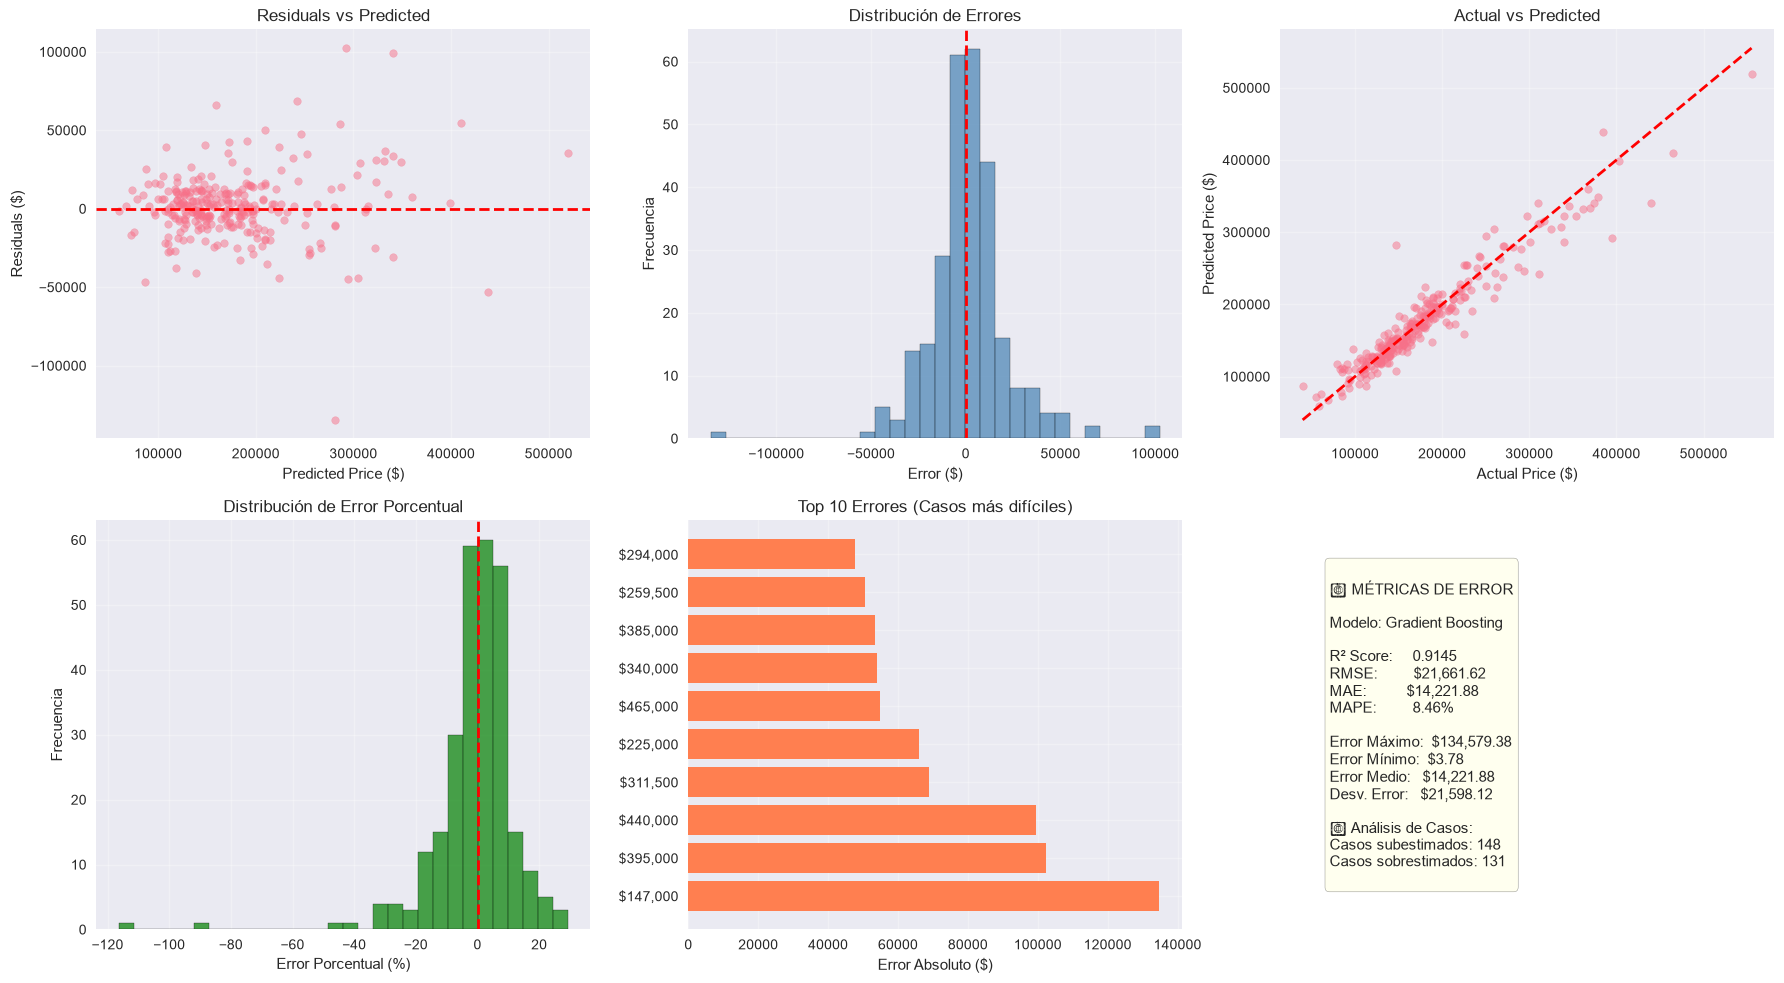


🔍 TOP 10 CASOS CON MAYOR ERROR:
     Actual  Predicted      Error  Pct_Error
67   147000  281579.38 -134579.38     -91.55
215  395000  292606.77  102393.23      25.92
4    440000  340443.22   99556.78      22.63
261  311500  242654.81   68845.19      22.10
239  225000  159077.62   65922.38      29.30
168  465000  410141.87   54858.13      11.80
234  340000  286087.70   53912.30      15.86
248  385000  438376.13  -53376.13     -13.86
183  259500  209035.20   50464.80      19.45
277  294000  246317.55   47682.45      16.22


In [19]:
# Análisis de errores del mejor modelo
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
y_pred = predictions[best_model_name]

# Calcular errores
errors = y_test - y_pred
residuals = y_test - y_pred

# Crear DataFrame de análisis
error_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Error': errors,
    'Abs_Error': np.abs(errors),
    'Pct_Error': (errors / y_test) * 100
})

# Identificar casos extremos
high_error = error_df.nlargest(10, 'Abs_Error')
low_error = error_df.nsmallest(10, 'Abs_Error')

# Visualizar
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Residuals plot
ax1 = axes[0, 0]
ax1.scatter(y_pred, residuals, alpha=0.5, s=30)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Predicted Price ($)')
ax1.set_ylabel('Residuals ($)')
ax1.set_title('Residuals vs Predicted')
ax1.grid(True, alpha=0.3)

# 2. Distribución de errores
ax2 = axes[0, 1]
ax2.hist(errors, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Error ($)')
ax2.set_ylabel('Frecuencia')
ax2.set_title('Distribución de Errores')
ax2.grid(True, alpha=0.3)

# 3. Actual vs Predicted
ax3 = axes[0, 2]
ax3.scatter(y_test, y_pred, alpha=0.5, s=30)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax3.set_xlabel('Actual Price ($)')
ax3.set_ylabel('Predicted Price ($)')
ax3.set_title('Actual vs Predicted')
ax3.grid(True, alpha=0.3)

# 4. Error porcentual
ax4 = axes[1, 0]
ax4.hist(error_df['Pct_Error'], bins=30, edgecolor='black', alpha=0.7, color='green')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Error Porcentual (%)')
ax4.set_ylabel('Frecuencia')
ax4.set_title('Distribución de Error Porcentual')
ax4.grid(True, alpha=0.3)

# 5. Top errores
ax5 = axes[1, 1]
top_errors = error_df.nlargest(10, 'Abs_Error')
ax5.barh(range(len(top_errors)), top_errors['Abs_Error'], color='coral')
ax5.set_yticks(range(len(top_errors)))
ax5.set_yticklabels([f"${v:,.0f}" for v in top_errors['Actual']])
ax5.set_xlabel('Error Absoluto ($)')
ax5.set_title('Top 10 Errores (Casos más difíciles)')
ax5.grid(True, alpha=0.3)

# 6. Métricas de error
ax6 = axes[1, 2]
ax6.axis('off')
metrics_text = f"""
📊 MÉTRICAS DE ERROR

Modelo: {best_model_name}

R² Score:     {r2_score(y_test, y_pred):.4f}
RMSE:         ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}
MAE:          ${mean_absolute_error(y_test, y_pred):,.2f}
MAPE:         {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%

Error Máximo:  ${np.max(np.abs(errors)):,.2f}
Error Mínimo:  ${np.min(np.abs(errors)):,.2f}
Error Medio:   ${np.mean(np.abs(errors)):,.2f}
Desv. Error:   ${np.std(errors):,.2f}

📊 Análisis de Casos:
Casos subestimados: {np.sum(errors > 0)}
Casos sobrestimados: {np.sum(errors < 0)}
"""
ax6.text(0.1, 0.5, metrics_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5))

plt.tight_layout()
plt.savefig('../reports/figures/model_comparison/error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Mostrar casos con mayores errores
print("\n🔍 TOP 10 CASOS CON MAYOR ERROR:")
print("="*60)
print(error_df.nlargest(10, 'Abs_Error')[['Actual', 'Predicted', 'Error', 'Pct_Error']].round(2))

📊 Generando curva de aprendizaje para Gradient Boosting...


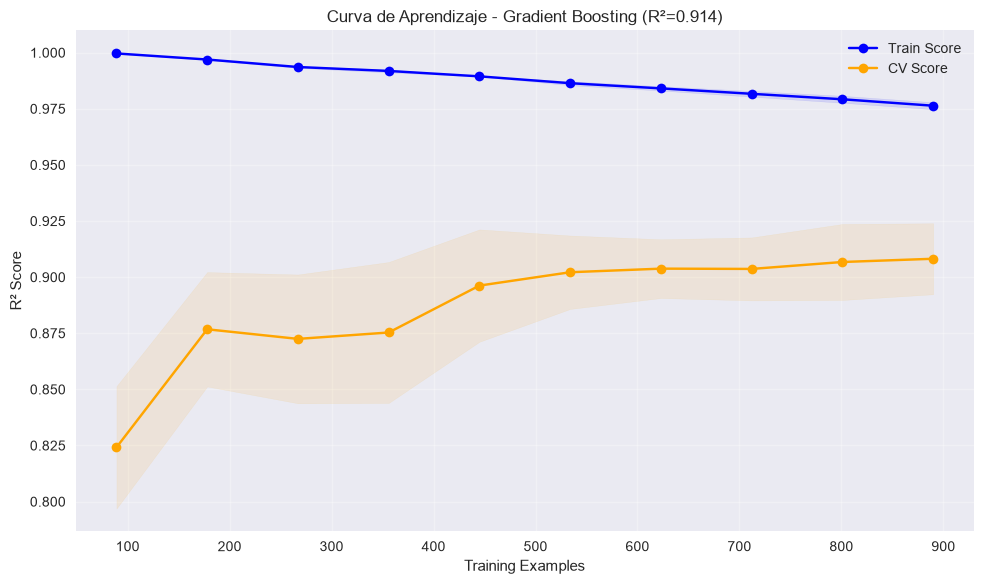


🔍 ANÁLISIS DE OVERFITTING/UNDERFITTING:
  - Gap Train-CV: 0.0682
  ✅ Balance adecuado entre bias y variance


In [20]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title, cv=5, n_jobs=-1):
    """
    Genera y grafica la curva de aprendizaje
    """
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=cv, n_jobs=n_jobs,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='r2'
    )
    
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)
    
    # Graficar
    plt.figure(figsize=(10, 6))
    
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='orange')
    
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train Score')
    plt.plot(train_sizes, test_mean, 'o-', color='orange', label='CV Score')
    
    plt.xlabel('Training Examples')
    plt.ylabel('R² Score')
    plt.title(f'Curva de Aprendizaje - {title}')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../reports/figures/model_comparison/learning_curve_{title.replace(" ", "_")}.png', 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    return train_mean, test_mean

# Curva para el mejor modelo
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print(f"📊 Generando curva de aprendizaje para {best_model_name}...")
train_scores, test_scores = plot_learning_curve(
    best_model, X_train, y_train, 
    title=f'{best_model_name} (R²={results_df.iloc[0]["R2_test"]:.3f})'
)

# Análisis de overfitting/underfitting
print("\n🔍 ANÁLISIS DE OVERFITTING/UNDERFITTING:")
print("="*60)

# Gap entre train y test
gap = train_scores[-1] - test_scores[-1]
print(f"  - Gap Train-CV: {gap:.4f}")

if gap > 0.1:
    print("  ⚠️ Posible OVERFITTING (gap > 0.1)")
    print("  💡 Sugerencia: Aumentar regularización o reducir complejidad")
elif gap < 0.01:
    print("  ⚠️ Posible UNDERFITTING (gap < 0.01)")
    print("  💡 Sugerencia: Aumentar complejidad del modelo")
else:
    print("  ✅ Balance adecuado entre bias y variance")

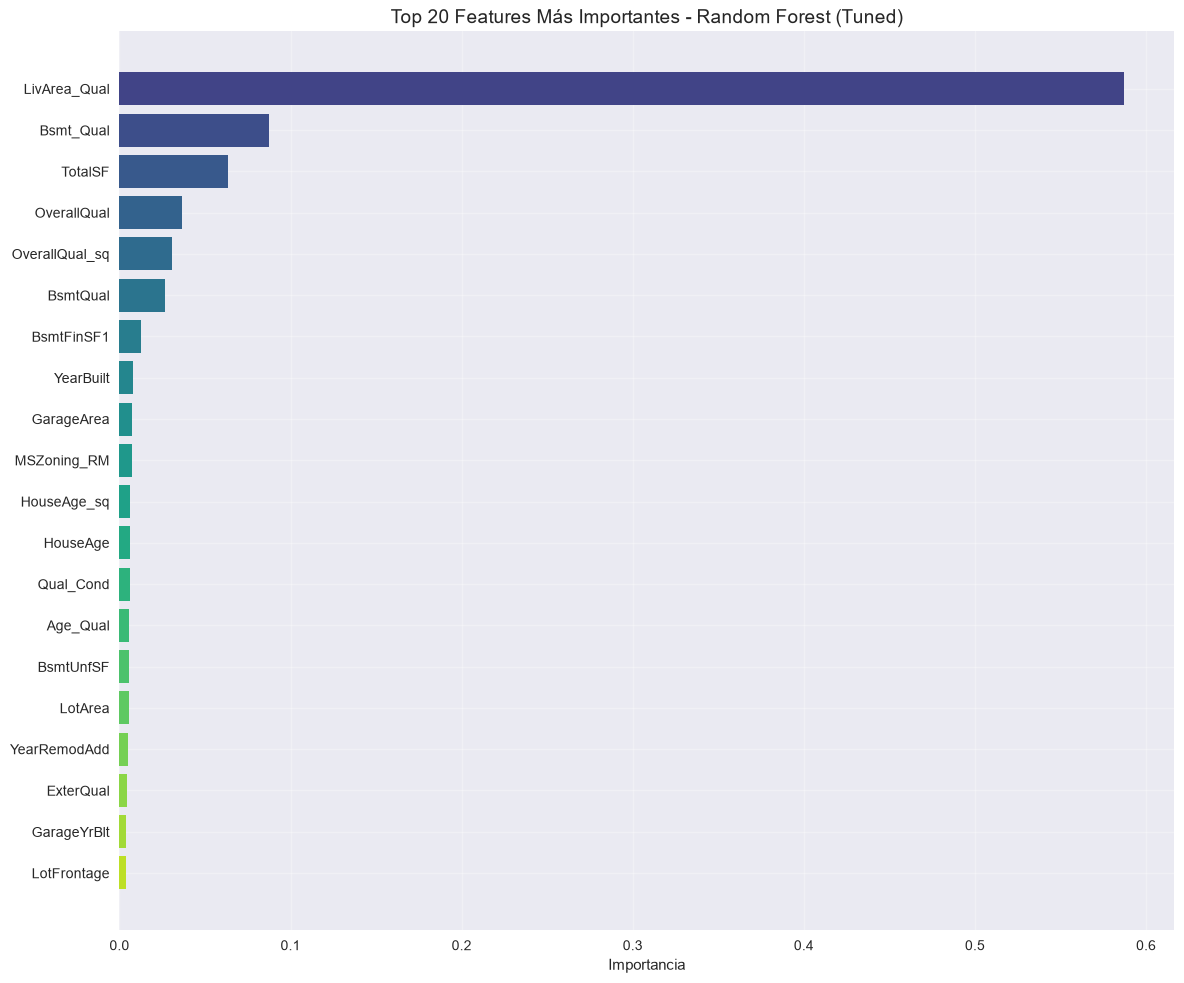


📊 TOP 20 FEATURES MÁS IMPORTANTES (Random Forest (Tuned)):
   1. LivArea_Qual             : 0.5870
   2. Bsmt_Qual                : 0.0876
   3. TotalSF                  : 0.0636
   4. OverallQual              : 0.0365
   5. OverallQual_sq           : 0.0307
   6. BsmtQual                 : 0.0265
   7. BsmtFinSF1               : 0.0127
   8. YearBuilt                : 0.0077
   9. GarageArea               : 0.0073
  10. MSZoning_RM              : 0.0073
  11. HouseAge_sq              : 0.0064
  12. HouseAge                 : 0.0062
  13. Qual_Cond                : 0.0059
  14. Age_Qual                 : 0.0057
  15. BsmtUnfSF                : 0.0055
  16. LotArea                  : 0.0054
  17. YearRemodAdd             : 0.0049
  18. ExterQual                : 0.0043
  19. GarageYrBlt              : 0.0040
  20. LotFrontage              : 0.0038

✅ Feature importance guardado en models_saved/feature_importance.csv


In [21]:
# Usar el mejor modelo o el Random Forest tuned
if 'best_rf' in locals():
    final_model = best_rf
    model_name = 'Random Forest (Tuned)'
else:
    final_model = trained_models[results_df.iloc[0]['Model']]
    model_name = results_df.iloc[0]['Model']

# Obtener feature importance (si el modelo lo soporta)
if hasattr(final_model, 'feature_importances_'):
    importances = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # Top 20
    top_20 = importances.head(20)
    
    # Visualizar
    plt.figure(figsize=(12, 10))
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_20)))
    plt.barh(top_20['Feature'], top_20['Importance'], color=colors)
    plt.xlabel('Importancia')
    plt.title(f'Top 20 Features Más Importantes - {model_name}', fontsize=14)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../reports/figures/model_comparison/final_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 TOP 20 FEATURES MÁS IMPORTANTES ({model_name}):")
    print("="*60)
    for i, (feature, importance) in enumerate(zip(top_20['Feature'], top_20['Importance']), 1):
        print(f"  {i:2d}. {feature:25s}: {importance:.4f}")
    
    # Guardar feature importance
    importances.to_csv('../models_saved/feature_importance.csv', index=False)
    print("\n✅ Feature importance guardado en models_saved/feature_importance.csv")
    
else:
    print(f"⚠️ {model_name} no soporta feature importance")

In [22]:
# Guardar el mejor modelo
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

# Si tenemos modelo tuned, usarlo
if 'best_rf' in locals():
    final_model = best_rf
    final_name = 'RandomForest_Tuned'
else:
    final_model = best_model
    final_name = best_model_name.replace(' ', '_')

# Guardar modelo
joblib.dump(final_model, f'../models_saved/{final_name}.pkl')
print(f"✅ Modelo guardado: models_saved/{final_name}.pkl")

# Guardar scaler (ya existe)
print("✅ Scaler ya guardado: models_saved/scaler.pkl")

# Guardar feature names
with open('../models_saved/feature_names.txt', 'w') as f:
    f.write('\n'.join(X_train.columns.tolist()))
print("✅ Feature names guardados: models_saved/feature_names.txt")

✅ Modelo guardado: models_saved/RandomForest_Tuned.pkl
✅ Scaler ya guardado: models_saved/scaler.pkl
✅ Feature names guardados: models_saved/feature_names.txt


In [23]:
# Celda 11.5: Guardar Gradient Boosting como modelo alternativo

# Recuperar el modelo de Gradient Boosting
gb_model = trained_models['Gradient Boosting']

# Guardar
joblib.dump(gb_model, '../models_saved/gradient_boosting.pkl')
print("✅ Gradient Boosting guardado: models_saved/gradient_boosting.pkl")

# Guardar también el mejor modelo final (puede ser el que elijas)
# Yo recomiendo Gradient Boosting para rendimiento, Random Forest para producción

✅ Gradient Boosting guardado: models_saved/gradient_boosting.pkl
